In [13]:
from langgraph.graph import StateGraph,END,START
from typing import TypedDict

In [14]:
class BMIState(TypedDict):
    height: float
    weight: float
    BMI: float

In [15]:
graph= StateGraph(BMIState)

In [24]:
def calculate_BMI(state: BMIState) -> BMIState:
    """
    Calculate the Body Mass Index (BMI) and store it in the state.
    """

    if state["height"] <= 0:
        raise ValueError("Height must be greater than 0.")

    if state["weight"] <= 0:
        raise ValueError("Weight must be greater than 0.")

    state["BMI"] = state["weight"] / state["height"] ** 2
    return state

In [17]:
graph.add_node("calculate_BMI", calculate_BMI)
graph.add_edge(START, "calculate_BMI")
graph.add_edge("calculate_BMI", END)

In [18]:
app = graph.compile()

In [26]:
output_state=app.invoke({'weight':80,'height':1.73})
output_state

{'height': 1.73, 'weight': 80, 'BMI': 26.729927495071667}

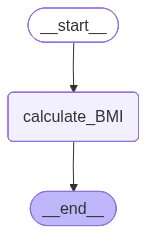

In [23]:
from IPython.display import Image
Image(app.get_graph().draw_mermaid_png())